# Question
### Do teams that advanced past the group stage have a significantly higher average possession percentage than teams eliminated in the group stage?

## Step 1 — Load raw match data and Round-of-32 reference list
- `raw_data.csv` holds only what was **manually collected** — team, match, and possession % per match.
- `round_of_32_teams.csv` holds the 32 team names that reached the Round of 32.


In [37]:
import pandas as pd

In [38]:
# raw match data
match_df = pd.read_csv("raw_data.csv")
print(f"Loaded {len(match_df)} rows from raw_data.csv")
match_df.head()

Loaded 144 rows from raw_data.csv


,team,match_id,possession_pct
0,Mexico,Mexico_vs_SouthAfrica_2026-06-11,61
1,South Africa,Mexico_vs_SouthAfrica_2026-06-11,40
2,Korea Republic,KoreaRepublic_vs_Czechia_2026-06-11,62
3,Czechia,KoreaRepublic_vs_Czechia_2026-06-11,38
4,Canada,Canada_vs_BosniaHerz2026-06-12,61


In [39]:
# round of 32 reference list
round_of_32_df = pd.read_csv("round_of_32_teams.csv")
print(f"Loaded {len(round_of_32_df)} teams from round_of_32_teams.csv")
round_of_32_df.head()

Loaded 32 teams from round_of_32_teams.csv


,team
0,South Africa
1,Canada
2,Brazil
3,Japan
4,Germany


## Step 2 — Data cleaning and wrangling
1. **Clean team names** — strip unwanted leading/trailing whitespace. This matters: `"Algeria"` and `"Algeria "` are treated as two different strings by pandas, which silently breaks any merge based on exact name matching.
2. **Merge** `match_df` with `round_of_32_df` to attach an `advanced` flag (1 = reached Round of 32, 0 = eliminated in the group stage)

In [40]:
# Clean whitespace from team names in both files
before = match_df["team"].copy()
match_df["team"] = match_df["team"].astype(str).str.strip()
n_cleaned = (before != match_df["team"]).sum()
print(f"Cleaned whitespace from 'team' in {n_cleaned} row(s) of raw_data.csv")

round_of_32_df["team"] = round_of_32_df["team"].astype(str).str.strip()

Cleaned whitespace from 'team' in 71 row(s) of raw_data.csv


In [41]:
# Attach the advanced/eliminated flag via merge
round_of_32_df = round_of_32_df.copy()
round_of_32_df["advanced"] = 1

df = match_df.merge(round_of_32_df, on="team", how="left")
df["advanced"] = df["advanced"].fillna(0).astype(int)

# Sanity check: any Round-of-32 team not found in the match data at all?
unmatched = set(round_of_32_df["team"]) - set(match_df["team"])
if unmatched:
    print(f"WARNING: these Round-of-32 teams were not found in raw_data.csv: {unmatched}")
else:
    print("All 32 Round-of-32 team names matched successfully.")

All 32 Round-of-32 team names matched successfully.


In [42]:
# Basic validation
df = df.dropna(subset=["possession_pct"])
df["possession_pct"] = df["possession_pct"].astype(float)

n_advanced = (df["advanced"] == 1).sum()
n_eliminated = (df["advanced"] == 0).sum()
print(f"Population sizes -> advanced: {n_advanced}, eliminated: {n_eliminated}")
if n_advanced != 96 or n_eliminated != 48:
    print("NOTE: population sizes differ from the expected 96 / 48")
    
df.head()

Population sizes -> advanced: 96, eliminated: 48


,team,match_id,possession_pct,advanced
0,Mexico,Mexico_vs_SouthAfrica_2026-06-11,61.0,1
1,South Africa,Mexico_vs_SouthAfrica_2026-06-11,40.0,1
2,Korea Republic,KoreaRepublic_vs_Czechia_2026-06-11,62.0,0
3,Czechia,KoreaRepublic_vs_Czechia_2026-06-11,38.0,0
4,Canada,Canada_vs_BosniaHerz2026-06-12,61.0,1


## Step 3 — Data preparation and sampling

Population = 96 advanced team-match records, 48 eliminated team-match records.

A simple random sample of **n = 30** is drawn from each group, without replacement, using a fixed random seed for reproducibility.

In [43]:
RANDOM_SEED = 42
SAMPLE_SIZE_PER_GROUP = 30

advanced_pop = df[df["advanced"] == 1]
eliminated_pop = df[df["advanced"] == 0]

advanced_sample = advanced_pop.sample(n=SAMPLE_SIZE_PER_GROUP, random_state=RANDOM_SEED, replace=False)
eliminated_sample = eliminated_pop.sample(n=SAMPLE_SIZE_PER_GROUP, random_state=RANDOM_SEED, replace=False)

adv_vals = advanced_sample["possession_pct"].values
elim_vals = eliminated_sample["possession_pct"].values

print(f"Advanced sample: n={len(adv_vals)}")
print(f"Eliminated sample: n={len(elim_vals)}")

Advanced sample: n=30
Eliminated sample: n=30


## Step 4 — Descriptive statistics

Mean, median, variance, Range & Inter Quartile Range of possession % for each sample group.

In [44]:
import statistics as stats
import numpy as np

In [45]:
def print_descriptives(sample, label):
    sample_list = list(sample)
    x_bar = stats.mean(sample_list)
    median = stats.median(sample_list)

    s_square = np.array(sample_list).var(ddof=1)   
    s = np.array(sample_list).std(ddof=1)         

    the_range = np.max(sample_list) - np.min(sample_list)
    pct25 = np.percentile(sample_list, 25)
    pct75 = np.percentile(sample_list, 75)
    iqr = pct75 - pct25

    print(f"--- {label} ---")
    print("Mean: %.2f" % x_bar)
    print("Median: %.2f" % median)
    print("Sample variance: %.2f. Sample std. dev.: %.2f." % (s_square, s))
    print("Range: %.2f" % the_range)
    print("IQR: %.2f. 25th percentile: %.2f. 75th percentile: %.2f" % (iqr, pct25, pct75))
    print()

    return x_bar, s

adv_mean, adv_sd = print_descriptives(adv_vals, "Advanced")
elim_mean, elim_sd = print_descriptives(elim_vals, "Eliminated")

--- Advanced ---
Mean: 53.03
Median: 54.50
Sample variance: 174.38. Sample std. dev.: 13.21.
Range: 53.00
IQR: 18.50. 25th percentile: 43.25. 75th percentile: 61.75

--- Eliminated ---
Mean: 42.67
Median: 40.00
Sample variance: 144.85. Sample std. dev.: 12.04.
Range: 51.00
IQR: 13.25. 25th percentile: 34.25. 75th percentile: 47.50



### Visualise the two groups

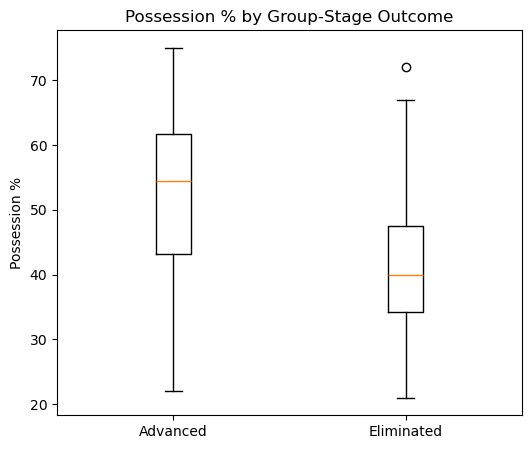

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([adv_vals, elim_vals], tick_labels=["Advanced", "Eliminated"])
ax.set_ylabel("Possession %")
ax.set_title("Possession % by Group-Stage Outcome")
plt.show()

### Compare mean possession % between groups

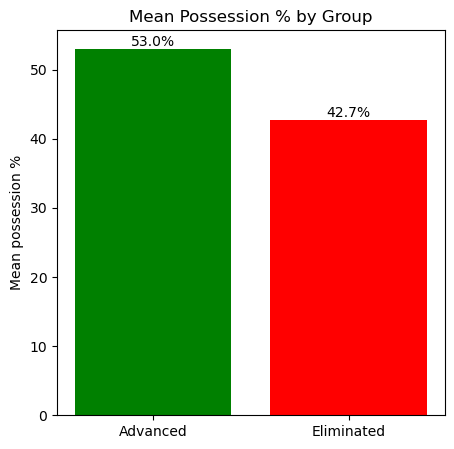

In [59]:
fig, ax = plt.subplots(figsize=(5, 5))
means = [adv_mean, elim_mean]
bars = ax.bar(["Advanced", "Eliminated"], means, color=["Green", "Red"])
ax.bar_label(bars, fmt="%.1f%%")
ax.set_ylabel("Mean possession %")
ax.set_title("Mean Possession % by Group")
plt.show()

### Compare the shape of each group's sample

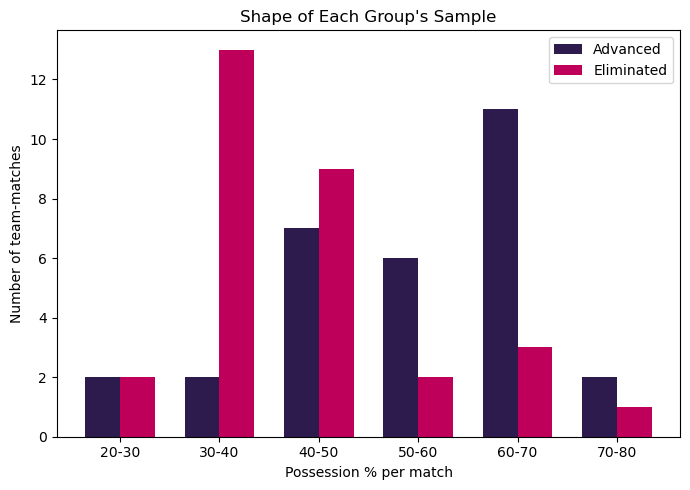

In [60]:
bins = [20, 30, 40, 50, 60, 70, 80]
bin_labels = ["20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]
adv_counts, _ = np.histogram(adv_vals, bins=bins)
elim_counts, _ = np.histogram(elim_vals, bins=bins)

x = np.arange(len(bin_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width / 2, adv_counts, width=width, label="Advanced", color="#2D1B4E")
ax.bar(x + width / 2, elim_counts, width=width, label="Eliminated", color="#BE005A")
ax.set_xticks(x)
ax.set_xticklabels(bin_labels)
ax.set_xlabel("Possession % per match")
ax.set_ylabel("Number of team-matches")
ax.set_title("Shape of Each Group's Sample")
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 — Inferential statistics: Confidence interval

95% confidence interval for the mean possession % of the **Advanced** group

In [ ]:
import math
import scipy.stats as st
import statsmodels.stats.weightstats as stm

x_bar = adv_mean
s = adv_sd
n = len(adv_vals)
print("Mean: %.2f. Standard deviation: %.2f. Size: %d." % (x_bar, s, n))

# z-score for 95% confidence level
z_score = st.norm.ppf(q=0.975)
print("Z-statistic: %.2f" % z_score)

# standard error
std_err = s / math.sqrt(n)
print("Standard error: %.2f" % std_err)

# margin of error
mrg_err = z_score * std_err
print("Margin of error: %.2f" % mrg_err)

# confidence interval 
ci_low = x_bar - mrg_err
ci_upp = x_bar + mrg_err
print("Confidence Interval of the mean: %.2f to %.2f" % (ci_low, ci_upp))

Mean: 53.03. Standard deviation: 13.21. Size: 30.
Z-statistic: 1.96
Standard error: 2.41
Margin of error: 4.73
Confidence Interval of the mean: 48.31 to 57.76


### Interpretation

We are 95% confident that the true mean possession % of teams that advanced to the Round of 32 lies within this interval — not that there's a 95% probability the true mean falls in it (the true mean is fixed; it's the interval-construction procedure that succeeds 95% of the time in the long run).

## Step 6 — Inferential statistics: Two-sample t-test

Following this unit's 4-Step Process for hypothesis testing (State → Plan → Solve → Conclude).

### 1: State

Do teams that advanced past the group stage have a significantly higher average possession % than teams eliminated in the group stage?

### 2: Plan

- H₀: mean possession % of Advanced teams = mean possession % of Eliminated teams
- H₁: mean possession % of Advanced teams ≠ mean possession % of Eliminated teams (two-sided test, no specific direction assumed in advance)
- α = 0.05
- Test: two-sample (independent) t-test, following `two-sample-t-test.py`

### 3: Solve

**Phase 1 — check random sampling:** the samples were drawn using simple random sampling without replacement (Step 3 above), satisfying this condition.


**Phase 2 — check normality:** a histogram of each sample is plotted below to visually check whether the possession % values appear roughly normally distributed.

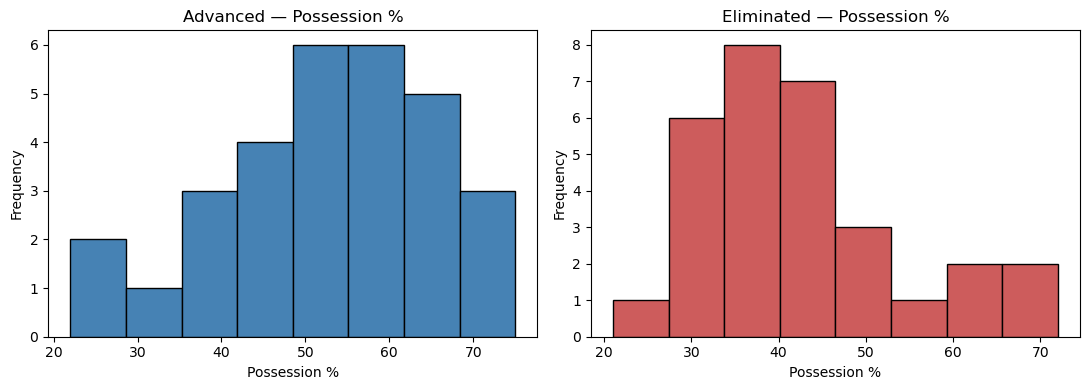

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(adv_vals, color="steelblue", edgecolor="black", bins=8)
axes[0].set_title("Advanced — Possession %")
axes[0].set_xlabel("Possession %")
axes[0].set_ylabel("Frequency")

axes[1].hist(elim_vals, color="indianred", edgecolor="black", bins=8)
axes[1].set_title("Eliminated — Possession %")
axes[1].set_xlabel("Possession %")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

- The Advanced group's histogram shows a roughly symmetric, unimodal distribution consistent with an approximately normal shape. The Eliminated group's histogram shows a right-skewed distribution, with most values concentrated between 30–45% possession and a thinning tail extending toward 60–70%. 
- Since the sample size for each group is n=30, satisfying the Central Limit Theorem's threshold of n≥30, the sampling distribution of the mean is still expected to be approximately normal despite this skew in the underlying data. 
- The t-test result is therefore treated as reasonably reliable, with the Eliminated group's skew noted as a minor limitation, consistent with the same caveat used in this unit's one-sample t-test example.

**Phase 3 — compute basic statistics:** mean, standard deviation, and size of each sample

In [ ]:
# Basic statistics of sample 1 (Advanced)
x_bar1 = st.tmean(adv_vals)
s1 = st.tstd(adv_vals)
n1 = len(adv_vals)

# Basic statistics of sample 2 (Eliminated)
x_bar2 = st.tmean(elim_vals)
s2 = st.tstd(elim_vals)
n2 = len(elim_vals)

print("Sample 1 (Advanced):    mean=%.2f, std=%.2f, n=%d" % (x_bar1, s1, n1))
print("Sample 2 (Eliminated):  mean=%.2f, std=%.2f, n=%d" % (x_bar2, s2, n2))

Sample 1 (Advanced):    mean=53.03, std=13.21, n=30
Sample 2 (Eliminated):  mean=42.67, std=12.04, n=30


**Phase 4 & 5 — compute the t-statistic score and p-value**

In [ ]:
t_stats, p_val = st.ttest_ind_from_stats(
    x_bar1, s1, n1,
    x_bar2, s2, n2,
    equal_var=False,
    alternative='two-sided'
)

print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val < 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")


 Computing t* ...
	 t-statistic (t*): 3.18

 Computing p-value ...
	 p-value: 0.0024

 Conclusion:
	 We reject the null hypothesis.


### 4: Conclude

- *t*(29) = 3.18, *p* = .002.

The p-value suggests that if the null hypothesis were true, there is less than 1% chance of observing a difference this large between the two groups' mean possession %. This provides evidence that teams which advanced past the group stage do, on average, have higher ball possession than teams eliminated in the group stage.



**Discussion / limitations:**
- Each team contributes 3 group-stage matches, so observations within a group are not fully independent of one another — a limitation worth acknowledging even though matches are treated as independent units of analysis here.
- The 32/16 team split is specific to this tournament's bracket and results, so conclusions are scoped to the FIFA World Cup 2026 rather than football more generally.